<a href="https://colab.research.google.com/github/Cousar/Colab-codes-for-TE-project/blob/main/Whiskers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import numpy as np           # For numerical operations
import pandas as pd          # For handling tabular data
import seaborn as sns        # For advanced statistical plotting
import matplotlib.pyplot as plt    # For controlling plot appearance
from matplotlib.lines import Line2D # Import Line2D for creating custom legend handles

def plot_whisker_from_2d_with_hue(data_matrix, group_labels, hue_labels,
                                  title="Grouped Boxplot with Hue",
                                  x_label="Group", y_label="Value",
                                  custom_palette=None):
    """
    Plots a grouped boxplot with hue from a 2D matrix.

    Parameters:
    - data_matrix: List of lists. Each inner list contains numerical values from one group.
    - group_labels: A label for each inner list in data_matrix (e.g., 'Group A', 'Group B').
    - hue_labels: A second label (e.g., 'Control' or 'Treated') for each inner list.
    - title: The plot's title.
    - x_label: Label for the x-axis (grouping category).
    - y_label: Label for the y-axis (numerical values).
    - custom_palette: Optional dict to customize hue colors.
    """

    # Check that all input lists are the same length
    assert len(data_matrix) == len(group_labels) == len(hue_labels), "Length mismatch!"

    # Prepare flat lists to construct a DataFrame
    flat_values = []      # All individual data points
    flat_groups = []      # Corresponding group label for each point
    flat_hues = []        # Corresponding hue label for each point

    # Loop over all sublists in the matrix along with their labels
    for values, g_label, h_label in zip(data_matrix, group_labels, hue_labels):
        for v in values:
            flat_values.append(v)       # Add each value to the flat list
            flat_groups.append(g_label) # Add corresponding group label
            flat_hues.append(h_label)   # Add corresponding hue label

    # Create a long-form DataFrame for Seaborn
    df = pd.DataFrame({
        "Value": flat_values,         # Numerical measurements
        x_label: flat_groups,         # X-axis grouping label
        "Category": flat_hues         # Hue grouping
    })

    # Set the plotting style to Seaborn's dark grid background
    sns.set_theme(style="whitegrid", context="talk")

    # If no custom colors were provided, generate one
    if custom_palette is None:
        hue_unique = list(set(hue_labels))           # Unique hue categories
        base_colors = sns.color_palette("Set1", n_colors=len(hue_unique))  # Auto-color
        custom_palette = dict(zip(hue_unique, base_colors))   # Map each hue to a color

    # Create a new figure of appropriate size
    plt.figure(figsize=(12, 6))

    # Build the boxplot with hue categories
    ax = sns.boxplot( # Assign the axes object to a variable 'ax'
        x=x_label,                   # Grouping category on X-axis
        y="Value",                   # Numerical values on Y-axis
        hue="Category",              # Secondary grouping (hue)
        data=df,                     # Use the long-form DataFrame we built
        palette=custom_palette,      # Use the custom color palette
        width=0.6,                   # Width of each box
        linewidth=0.8,               # Thickness of box lines
        showmeans=True,              # Show the mean as a special marker
        meanprops=dict(              # Customize the mean marker
            marker="D",                  # Diamond marker
            markerfacecolor="black", # Fill color of the marker
            markeredgecolor="white", # Edge color
            markersize=6             # Size of the marker
        ),
        fliersize=6                  # Size of the outlier points
    )

    # Add title and axis labels with formatting
    plt.title(title, fontsize=16)
    plt.xlabel(x_label, fontsize=14)
    plt.ylabel(y_label, fontsize=14)

    # Make axis ticks easier to read
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # Step 1: Find the minimum and maximum values in the matrix (using input data_matrix)
    min_value = np.min(data_matrix)   # Min value from the provided data_matrix
    max_value = np.max(data_matrix)   # Max value from the provided data_matrix

    # Step 2: Round the min_value and max_value to the nearest multiple of 100
    adjusted_min = np.floor(min_value / 100) * 100   # Round down the min value
    adjusted_max = np.ceil(max_value / 100) * 100    # Round up the max value

    # Step 3: Generate the ticks in intervals of 100
    yticks = np.arange(adjusted_min, adjusted_max + 100, 100)

    # Set the y-ticks dynamically based on the calculated range
    plt.yticks(yticks)   # Apply the dynamically calculated y-ticks

    # First legend for hue categories
    hue_legend = ax.legend(

        title_fontsize=12,
        fontsize=11,
        loc='upper left',
        bbox_to_anchor=(1.02, 1)
    )
    # Add the first legend to the axes to prevent it from being overwritten by a second legend
    ax.add_artist(hue_legend)

    # Create proxy artists for the mean and median and outliers legend
    mean_proxy = Line2D([0], [0], marker='D', color='w', markerfacecolor='black',
                        markeredgecolor='white', markersize=6, label='Mean')

    # The median is represented by a line within the box.
    # We can create a proxy line for it. The color of the median line in seaborn boxplot is typically dark grey or black by default.
    # We'll use black for simplicity or you can inspect a generated plot for the exact color.
    median_proxy = Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Median')
    #Outliers:
    outlier_proxy = Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
                        markeredgecolor='black', markersize=6, label='Outlier')
    # Create a second legend for mean and median
    plt.legend(handles=[mean_proxy, median_proxy, outlier_proxy],
               loc='upper left',
               bbox_to_anchor=(1.02, 0.8), # Adjust position to be below the first legend

               title_fontsize=12,
               fontsize=11)

    # Optionally, highlight the horizontal line at y=0 (or another value)
    plt.axhline(0, color='red', linewidth=1.5, linestyle='--')

    # Fit layout tightly so nothing overlaps
    plt.tight_layout()

    # Show the final plot
    plt.savefig("my_plot.png", dpi=600, bbox_inches='tight')
    plt.show()

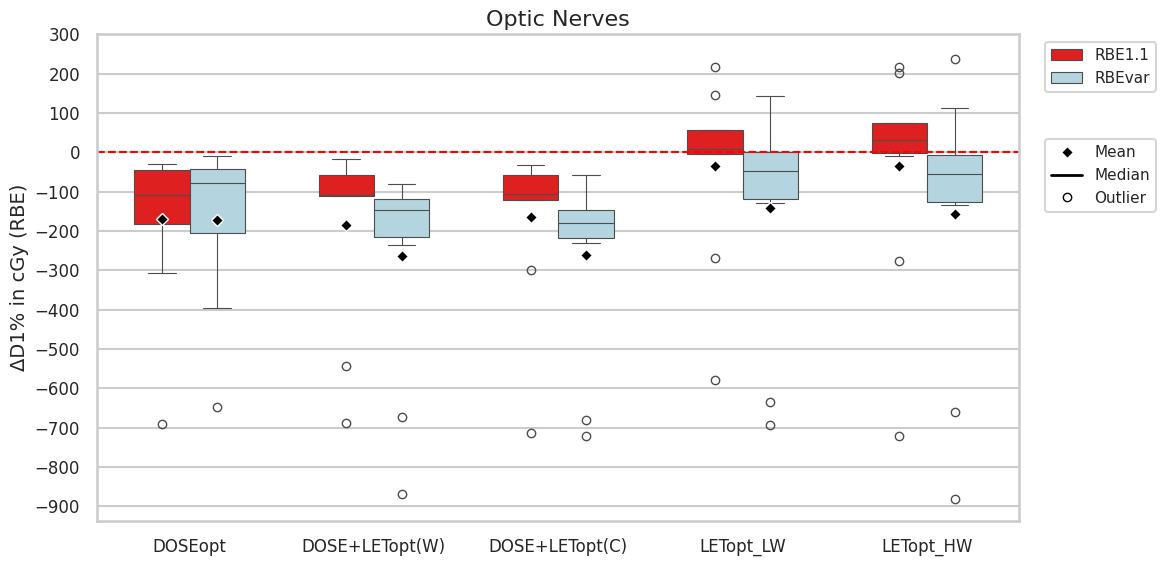

In [ ]:

# Each group has an associated group name and hue condition
# Optic Nerves

# List of numerical values grouped into sublists
data_matrix = [
    [-39, -308, -108, -117, -691, -203, -44, -29, -45, -108],  # DOSEopt - RBE1.1
    [-78, -397, -172, -42, -647, -216, -41, -10, -48, -78],  # DOSEopt - RBEvar
    [-58, -544, -109, -111, -688, -111, -38, -16, -57, -109],  # DOSE+LETopt(warm) - RBE1.1
    [-158, -869, -148, -113, -672, -235, -134, -89, -81, -148],  # DOSE+LETopt(warm) - RBEvar
    [-62, -300, -121, -119, -714, -106, -57, -33, -36, -106],  # DOSE+LETopt(cold) - RBE1.1
    [-169, -682, -180, -138, -722, -231, -181, -57, -64, -180],  # DOSE+LETopt(cold) - RBEvar
    [57, -269, 9, 54, -579, -2, -4, 218, 146, 9],  # LETopt_LW - RBE1.1
    [-48, -635, -43, 15, -694, -128, -88, 112, 142, -48],  # LETopt_LW - RBEvar
    [72, -277, 30, 74, -721, 24, -10, 218, 202, 30],  # LETopt_HW - RBE1.1
    [-54, -661, -51, 8, -881, -134, -102, 112, 236, -54]  # LETopt_HW - RBEvar
]

# X-axis group label for each sublist
group_labels = [
    "DOSEopt", "DOSEopt",
    "DOSE+LETopt(W)", "DOSE+LETopt(W)", # Added comma here
    "DOSE+LETopt(C)", "DOSE+LETopt(C)", # Added comma here
    "LETopt_LW", "LETopt_LW", # Added comma here
    "LETopt_HW", "LETopt_HW" # Added comma here
]

# Hue category for each sublist (e.g., Treatment condition)
hue_labels = [
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar"
]

# Optional: Define specific colors for each hue
custom_colors = {
    "RBE1.1": "#FF0000",   # Red
    "RBEvar": "#ADD8E6"    # Blue
}

# Call the function to generate the plot
plot_whisker_from_2d_with_hue(
    data_matrix,
    group_labels,
    hue_labels,
    #title="D1% changes of optic nerves in EPs copmared to CAP  for OC",
    title="Optic Nerves",
    x_label="",
    y_label="ΔD1% in cGy (RBE)",
    custom_palette=custom_colors
)


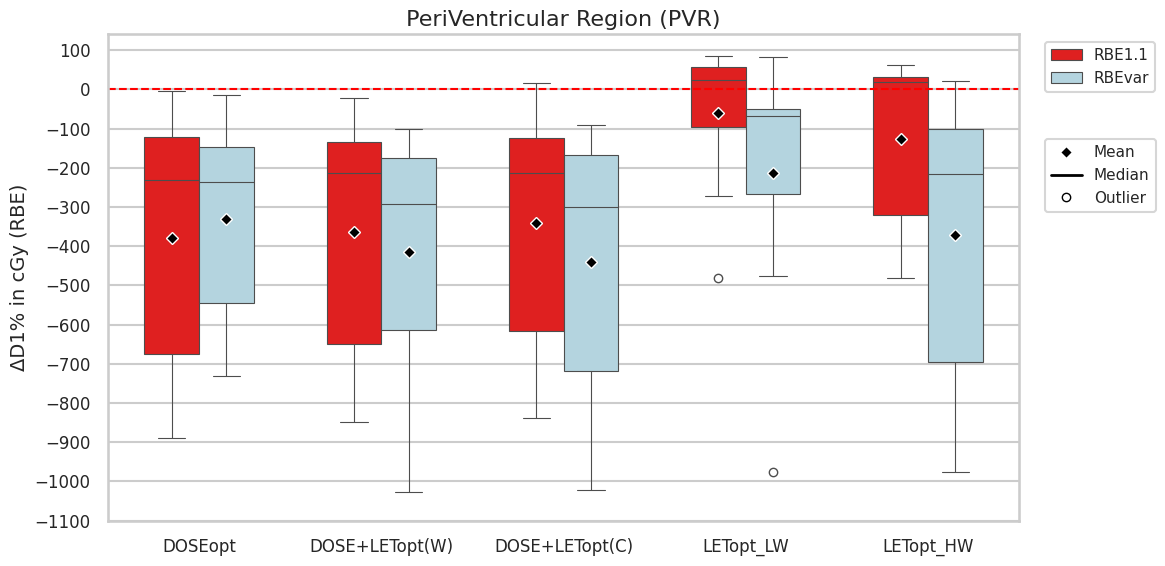

In [ ]:
# Each group has an associated group name and hue condition
# PVR

# List of numerical values grouped into sublists
data_matrix = [
    [-4,	-10,	-97,	-686,	-646,	-812,	-209,	-193,	-888,	-251],  # DOSEopt - RBE1.1
    [-14,	-52,	-133,	-476,	-660,	-569,	-197,	-276,	-732,	-193],  # DOSEopt - RBEvar
    [-27,	-21,	-114,	-722,	-650,	-848,	-198,	-194,	-647,	-227],  # DOSE+LETopt(warm) - RBE1.1
    [-102,	-145,	-142,	-561,	-684,	-631,	-297,	-264,	-1026,	-290],  # DOSE+LETopt(warm) - RBEvar
    [-4,	16,	-108,	-706,	-652,	-839,	-207,	-174,	-506,	-221],  # DOSE+LETopt(cold) - RBE1.1
    [-92,	-120,	-139,	-714,	-719,	-747,	-302,	-250,	-1022,	-298],  # DOSE+LETopt(cold) - RBEvar
    [35,	59,	85,	-112,	-51,	-272,	54,	11,	-481,	58],  # LETopt_LW - RBE1.1
    [-54,	-64,	83,	-295,	-186,	-476,	-72,	-48,	-976,	-40],  # LETopt_LW - RBEvar
    [21,	34,	62,	-328,	-297,	-370,	15,	28,	-481,	52],  # LETopt_HW - RBE1.1
    [-122,	-155,	22,	-728,	-593,	-744,	-276,	-55,	-976,	-93]  # LETopt_HW - RBEvar
]

# X-axis group label for each sublist
group_labels = [
    "DOSEopt", "DOSEopt",
    "DOSE+LETopt(W)", "DOSE+LETopt(W)", # Added comma here
    "DOSE+LETopt(C)", "DOSE+LETopt(C)", # Added comma here
    "LETopt_LW", "LETopt_LW", # Added comma here
    "LETopt_HW", "LETopt_HW" # Added comma here
]

# Hue category for each sublist (e.g., Treatment condition)
hue_labels = [
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar"
]

# Optional: Define specific colors for each hue
custom_colors = {
    "RBE1.1": "#FF0000",   # Red
    "RBEvar": "#ADD8E6"    # Blue
}

# Call the function to generate the plot
plot_whisker_from_2d_with_hue(
    data_matrix,
    group_labels,
    hue_labels,
    #title="D1% changes of PVR in EPs copmared to CAP  for OC
    title=" PeriVentricular Region (PVR) ",
    x_label="",
    y_label="ΔD1% in cGy (RBE)",
    custom_palette=custom_colors
)

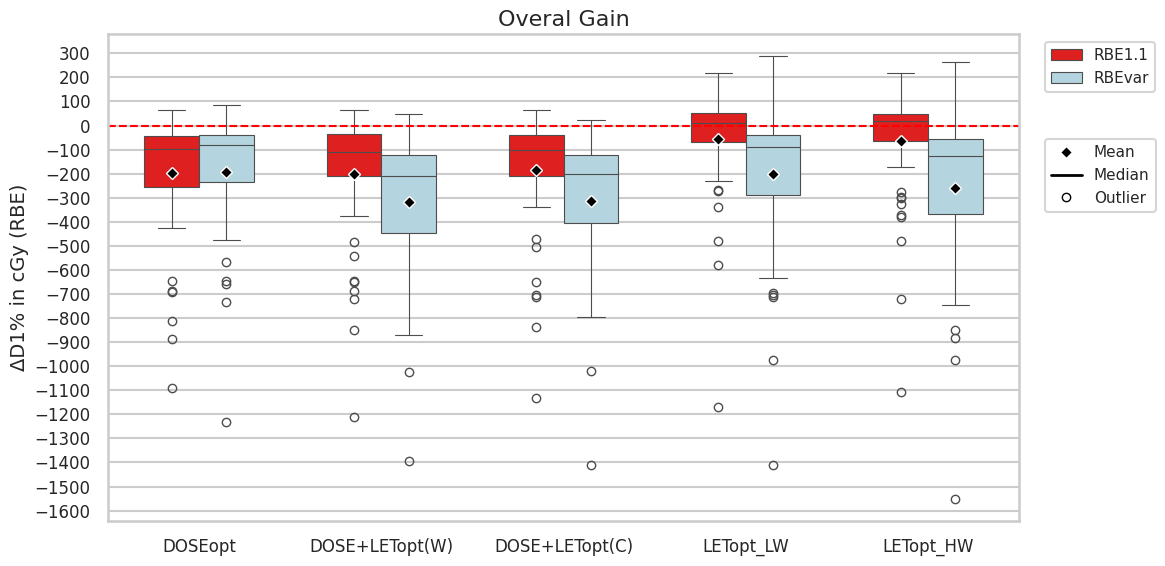

In [ ]:
# Each group has an associated group name and hue condition
# Overall enhanced normal tissue sparing

# List of numerical values grouped into sublists
data_matrix = [
    [-42,	0,	23,	40,	1,	66,	12,	-82,	-70,	-426,	-6,	-92,	-82,	-39,	-308,	-108,	-117,	-691,	-203,	-44,	-29,	-45,	-108,	-91,	-96,	-294,	-54,	-99,	-96,	-257,	-1090,	-294,	-54,	-99,	-257,	-4,	-10,	-97,	-686,	-646,	-812,	-209,	-193,	-888,	-251,	-230],  # DOSEopt - RBE1.1
    [3,	9,	29,	-56,	-14,	84,	6,	-84,	-209,	-372,	-61,	-52,	-84,	-78,	-397,	-172,	-42,	-647,	-216,	-41,	-10,	-48,	-78,	-76,	-273,	-224,	-38,	-6,	-76,	-397,	-1234,	-224,	-38,	-6,	-224,	-14,	-52,	-133,	-476,	-660,	-569,	-197,	-276,	-732,	-193,	-236.5],  # DOSEopt - RBEvar
    [3,	64,	13,	-54,	23,	64,	18,	-159,	-45,	-482,	-5,	-92,	-92,	-58,	-544,	-109,	-111,	-688,	-111,	-38,	-16,	-57,	-109,	-100,	-141,	-375,	-122,	-88,	-122,	-290,	-35,	-1213,	-33,	-188,	-188,	-27,	-21,	-114,	-722,	-650,	-848,	-198,	-194,	-647,	-227,	-212.5],  # DOSE+LETopt(warm) - RBE1.1
    [-15,	-168,	-68,	-285,	-33,	46,	-50.5,	-262,	-506,	-783,	-117,	-157,	-262,	-158,	-869,	-148,	-113,	-672,	-235,	-134,	-89,	-81,	-148,	-148,	-463,	-665,	-187,	-23,	-187,	-791,	-282,	-1392,	14,	-395,	-395,	-102,	-145,	-142,	-561,	-684,	-631,	-297,	-264,	-1026,	-290,	-293.55],  # DOSE+LETopt(warm) - RBEvar
    [4,	66,	5,	-49,	63,	20,	12.5,	-160,	39,	-471,	-20,	-66,	-66,	-62,	-300,	-121,	-119,	-714,	-106,	-57,	-33,	-36,	-106,	-101,	-134,	-337,	-99,	-75,	-101,	-211,	-43,	-63,	-1131,	-129,	-129,	-4,	16,	-108,	-706,	-652,	-839,	-207,	-174,	-506,	-221,	-214],  # DOSE+LETopt(cold) - RBE1.1
    [--5,	-157,	-61,	-284,	24,	-42,	-51.5,	-248,	-437,	-794,	-109,	-133,	-248,	-169,	-682,	-180,	-138,	-722,	-231,	-181,	-57,	-64,	-180,	-147,	-448,	-626,	-171,	7,	-171,	-710,	-226,	-36,	-1412,	-307,	-307,	-92,	-120,	-139,	-714,	-719,	-747,	-302,	-250,	-1022,	-298,	-300],  # DOSE+LETopt(cold) - RBEvar
    [-6,	61,	35,	-11,	36,	169,	35.5,	-85,	57,	-338,	23,	125,	23,	57,	-269,	9,	54,	-579,	-2,	-4,	218,	146,	9,	-39,	-101,	-229,	-42,	212,	-42,	-208,	-1168,	42,	-22,	-68,	-68,	35,	59,	85,	-112,	-51,	-272,	54,	11,	-481,	58,	23],  # LETopt_LW - RBE1.1
    [-18,	-169,	-45,	-260,	-28,	213,	-36.5,	-184,	-393,	-706,	-60,	64,	-184,	-48,	-635,	-43,	15,	-694,	-128,	-88,	112,	142,	-48,	-89,	-389,	-570,	-125,	287,	-125,	-712,	-1411,	-190,	13,	-287,	-287,	-54,	-64,	83,	-295,	-186,	-476,	-72,	-48,	-976,	-40,	-68],  # LETopt_LW - RBEvar
    [-4,	67,	35,	-35,	39,	163,	37,	-88,	128,	-379,	26,	80,	26,	72,	-277,	30,	74,	-721,	24,	-10,	218,	202,	30,	-36,	9,	-301,	-20,	207,	-20,	-173,	-1106,	101,	-16,	-66,	-66,	21,	34,	62,	-328,	-297,	-370,	15,	28,	-481,	52,	18],  # LETopt_HW - RBE1.1
    [-30,	-240,	-123,	-372,	-26,	105,	-76.5,	-203,	-381,	-849,	-75,	19,	-203,	-54,	-661,	-51,	8,	-881,	-134,	-102,	112,	236,	-54,	-73,	-347,	-651,	-108,	263,	-108,	-726,	-1550,	-153,	14,	-315,	-315,	-122,	-155,	22,	-728,	-593,	-744,	-276,	-55,	-976,	-93,	-215.5

]  # LETopt_HW - RBEvar
]

# X-axis group label for each sublist
group_labels = [
    "DOSEopt", "DOSEopt",
    "DOSE+LETopt(W)", "DOSE+LETopt(W)", # Added comma here
    "DOSE+LETopt(C)", "DOSE+LETopt(C)", # Added comma here
    "LETopt_LW", "LETopt_LW", # Added comma here
    "LETopt_HW", "LETopt_HW" # Added comma here
]

# Hue category for each sublist (e.g., Treatment condition)
hue_labels = [
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar"
]

# Optional: Define specific colors for each hue
custom_colors = {
    "RBE1.1": "#FF0000",   # Red
    "RBEvar": "#ADD8E6"    # Blue
}

# Call the function to generate the plot
plot_whisker_from_2d_with_hue(
    data_matrix,
    group_labels,
    hue_labels,
    #title="D1% changes of all OARs in EPs copmared to CAP  for OC"
    title="Overal Gain",
    x_label="",
    y_label="ΔD1% in cGy (RBE)",
    custom_palette=custom_colors
)

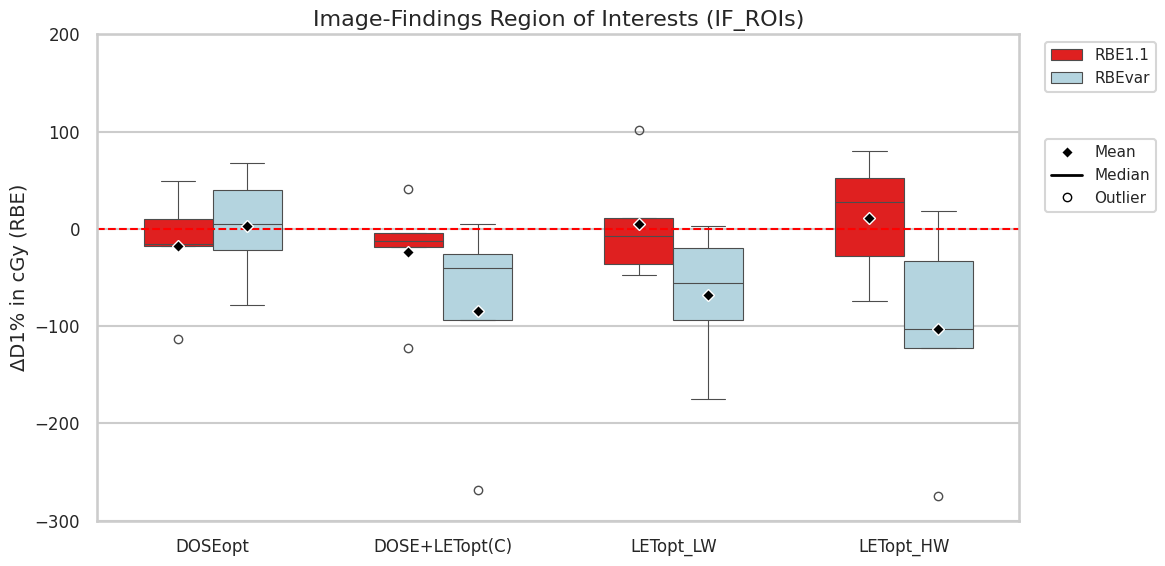

In [ ]:
# Each group has an associated group name and hue condition
# IF_ROIs

# List of numerical values grouped into sublists
data_matrix = [
    [10, 49, -113, -18, -16],  # DOSEopt - RBE1.1
    [68,	40,	-78,	-22,	5],  # DOSEopt - RBEvar
    [-13,	41,	-123,	-19,	-4],  # DOSE+LETopt(cold) - RBE1.1
    [-269,	-26,	-94,	-40,	5],  # DOSE+LETopt(cold) - RBEvar
    [102,	11,	-47,	-36,	-7],  # LETopt_LW - RBE1.1
    [-175,	-94,	-56,	-20,	3],  # LETopt_LW - RBEvar
    [80,	52,	-74,	-28,	28],  # LETopt_HW - RBE1.1
    [-275,	-103,	-122,	-33,	18]  # LETopt_HW - RBEvar
]

# X-axis group label for each sublist
group_labels = [
    "DOSEopt", "DOSEopt",
    "DOSE+LETopt(C)", "DOSE+LETopt(C)", # Added comma here
    "LETopt_LW", "LETopt_LW", # Added comma here
    "LETopt_HW", "LETopt_HW" # Added comma here
]

# Hue category for each sublist (e.g., Treatment condition)
hue_labels = [
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
]

# Optional: Define specific colors for each hue
custom_colors = {
    "RBE1.1": "#FF0000",   # Red
    "RBEvar": "#ADD8E6"    # Blue
}

# Call the function to generate the plot
plot_whisker_from_2d_with_hue(
    data_matrix,
    group_labels,
    hue_labels,
    #title="D1% changes of IF ROIs in EPs copmared to CAP  for IFC",
    title="Image-Findings Region of Interests (IF_ROIs)",
    x_label="",
    y_label="ΔD1% in cGy (RBE)",
    custom_palette=custom_colors
)

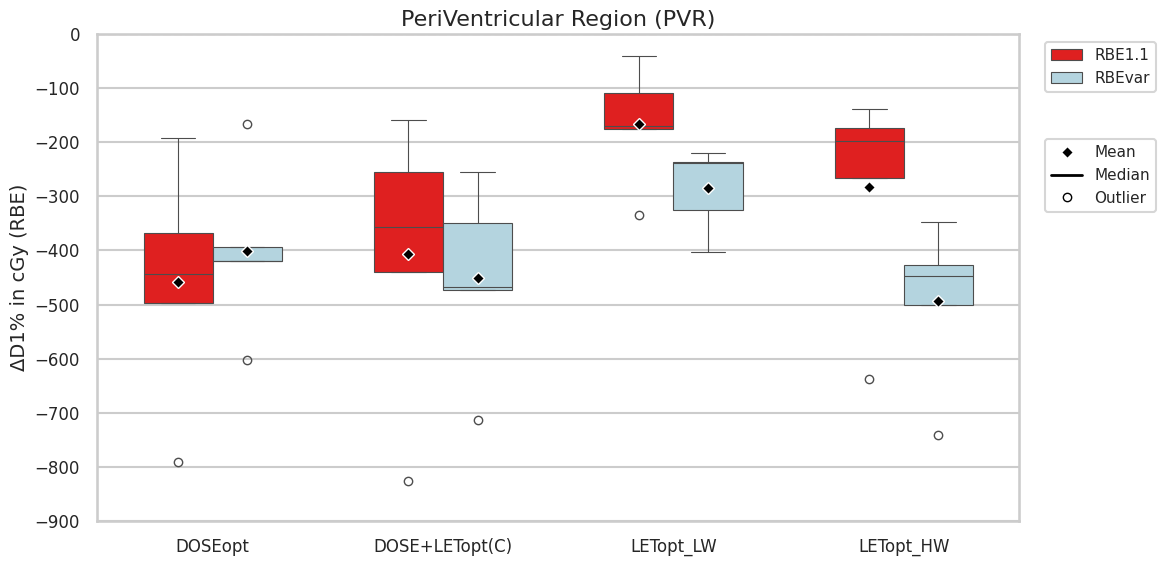

In [ ]:
# Each group has an associated group name and hue condition
# PVR, IFC  cohort

# List of numerical values grouped into sublists
data_matrix = [
    [-497,	-791,	-444,	-368,	-192],  # DOSEopt - RBE1.1
    [-393,	-602,	-420,	-420,	-166],  # DOSEopt - RBEvar
    [-357,	-826,	-440,	-254,	-158],  # DOSE+LETopt(cold) - RBE1.1
    [-467,	-713,	-473,	-349,	-254],  # DOSE+LETopt(cold) - RBEvar
    [-41,	-335,	-170,	-175,	-109],  # LETopt_LW - RBE1.1
    [-238,	-403,	-237,	-325,	-220],  # LETopt_LW - RBEvar
    [-197,	-638,	-266,	-173,	-139],  # LETopt_HW - RBE1.1
    [-501,	-741,	-448,	-427,	-348]  # LETopt_HW - RBEvar
]

# X-axis group label for each sublist
group_labels = [
    "DOSEopt", "DOSEopt",
    "DOSE+LETopt(C)", "DOSE+LETopt(C)", # Added comma here
    "LETopt_LW", "LETopt_LW", # Added comma here
    "LETopt_HW", "LETopt_HW" # Added comma here
]

# Hue category for each sublist (e.g., Treatment condition)
hue_labels = [
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
]

# Optional: Define specific colors for each hue
custom_colors = {
    "RBE1.1": "#FF0000",   # Red
    "RBEvar": "#ADD8E6"    # Blue
}

# Call the function to generate the plot
plot_whisker_from_2d_with_hue(
    data_matrix,
    group_labels,
    hue_labels,
    #title="D1% changes of PVR in EPs copmared to CAP  for IFC",
    title="PeriVentricular Region (PVR)",
    x_label="",
    y_label="ΔD1% in cGy (RBE)",
    custom_palette=custom_colors
)

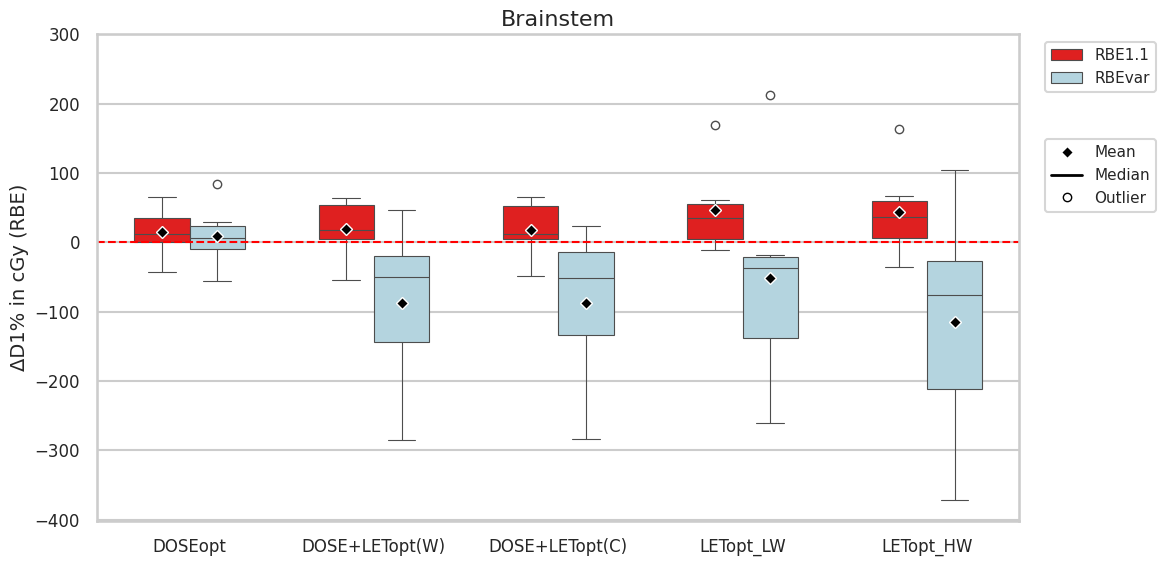

In [ ]:
# Each group has an associated group name and hue condition
# Brain Stem

# List of numerical values grouped into sublists
data_matrix = [
    [-42,	0,	23,	40,	1,	66],  # DOSEopt - RBE1.1
    [3,	9,	29,	-56,	-14,	84],  # DOSEopt - RBEvar
    [3,	64,	13,	-54,	23,	64],  # DOSE+LETopt(warm) - RBE1.1
    [-15,	-168,	-68,	-285,	-33,	46],  # DOSE+LETopt(warm) - RBEvar
    [4,	66,	5,	-49,	63,	20],  # DOSE+LETopt(cold) - RBE1.1
    [-5,	-157,	-61,	-284,	24,	-42],  # DOSE+LETopt(cold) - RBEvar
    [-6,	61,	35,	-11,	36,	169],  # LETopt_LW - RBE1.1
    [-18,	-169,	-45,	-260,	-28,	213],  # LETopt_LW - RBEvar
    [-4,	67,	35,	-35,	39,	163],  # LETopt_HW - RBE1.1
    [-30,	-240,	-123,	-372,	-26,	105]  # LETopt_HW - RBEvar
]

# X-axis group label for each sublist
group_labels = [
    "DOSEopt", "DOSEopt",
    "DOSE+LETopt(W)", "DOSE+LETopt(W)", # Added comma here
    "DOSE+LETopt(C)", "DOSE+LETopt(C)", # Added comma here
    "LETopt_LW", "LETopt_LW", # Added comma here
    "LETopt_HW", "LETopt_HW" # Added comma here
]

# Hue category for each sublist (e.g., Treatment condition)
hue_labels = [
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar"
]

# Optional: Define specific colors for each hue
custom_colors = {
    "RBE1.1": "#FF0000",   # Red
    "RBEvar": "#ADD8E6"    # Blue
}

# Call the function to generate the plot
plot_whisker_from_2d_with_hue(
    data_matrix,
    group_labels,
    hue_labels,
    title="Brainstem",
    x_label="",
    y_label="ΔD1% in cGy (RBE)",
    custom_palette=custom_colors
)

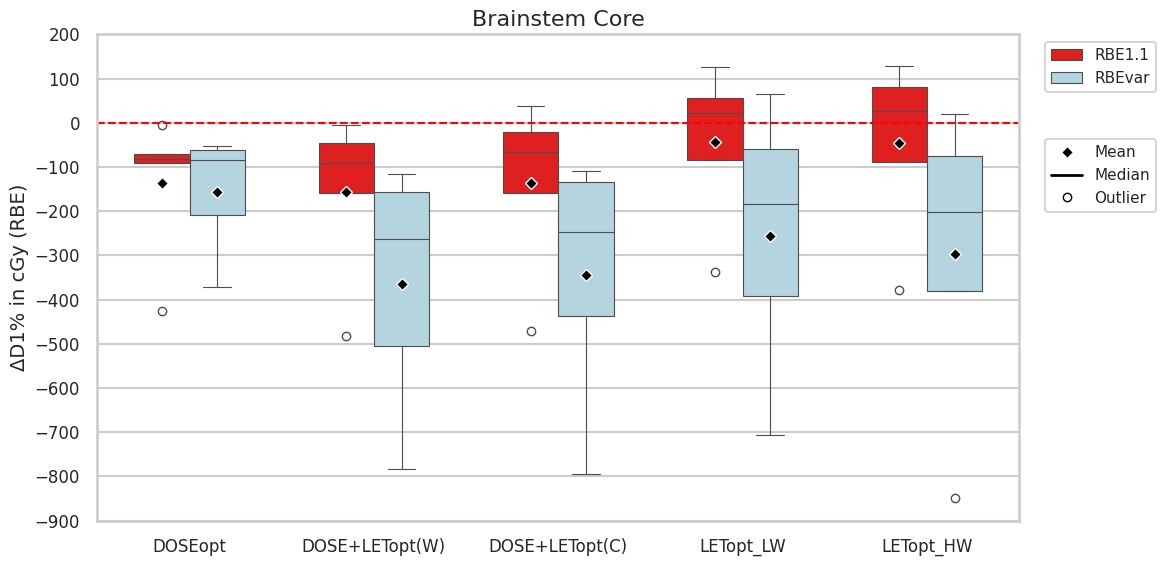

In [ ]:
# Each group has an associated group name and hue condition
# brain stem centre

# List of numerical values grouped into sublists
data_matrix = [
        [-82,	-70,	-426,	-6,	-92],  # DOSEopt - RBE1.1
    [-84,	-209,	-372,	-61,	-52],  # DOSEopt - RBEvar
    [-159,	-45,	-482,	-5,	-92],  # DOSE+LETopt(warm) - RBE1.1
    [-262,	-506,	-783,	-117,	-157],  # DOSE+LETopt(warm) - RBEvar
    [-160,	39,	-471,	-20,	-66],  # DOSE+LETopt(cold) - RBE1.1
    [-248,	-437,	-794,	-109,	-133],  # DOSE+LETopt(cold) - RBEvar
    [-85,	57,	-338,	23,	125],  # LETopt_LW - RBE1.1
    [-184,	-393,	-706,	-60,	64],  # LETopt_LW - RBEvar
    [-88,	128,	-379,	26,	80],  # LETopt_HW - RBE1.1
    [-203,	-381,	-849,	-75,	19]  # LETopt_HW - RBEvar
]

# X-axis group label for each sublist
group_labels = [
    "DOSEopt", "DOSEopt",
    "DOSE+LETopt(W)", "DOSE+LETopt(W)", # Added comma here
    "DOSE+LETopt(C)", "DOSE+LETopt(C)", # Added comma here
    "LETopt_LW", "LETopt_LW", # Added comma here
    "LETopt_HW", "LETopt_HW" # Added comma here
]

# Hue category for each sublist (e.g., Treatment condition)
hue_labels = [
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar"
]

# Optional: Define specific colors for each hue
custom_colors = {
    "RBE1.1": "#FF0000",   # Red
    "RBEvar": "#ADD8E6"    # Blue
}

# Call the function to generate the plot
plot_whisker_from_2d_with_hue(
    data_matrix,
    group_labels,
    hue_labels,
    title="Brainstem Core",
    x_label="",
    y_label="ΔD1% in cGy (RBE)",
    custom_palette=custom_colors
)

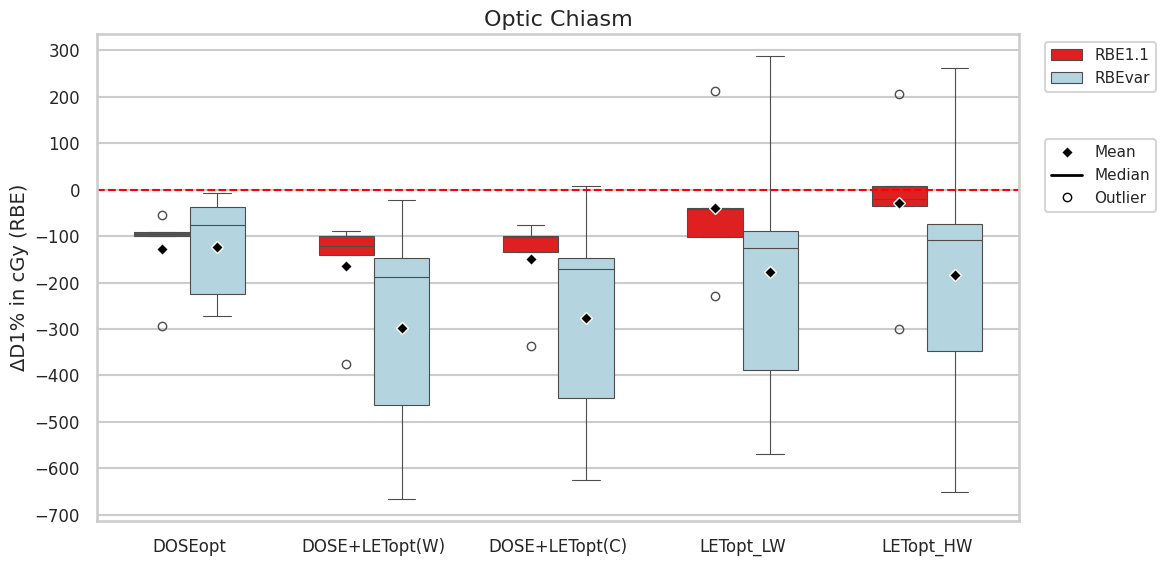

In [ ]:
# Each group has an associated group name and hue condition
# Chiasma

# List of numerical values grouped into sublists
data_matrix = [
     [-91,	-96,	-294,	-54,	-99],  # DOSEopt - RBE1.1
    [-76,	-273,	-224,	-38,	-6],  # DOSEopt - RBEvar
    [-100,	-141,	-375,	-122,	-88],  # DOSE+LETopt(warm) - RBE1.1
    [-148,	-463,	-665,	-187,	-23],  # DOSE+LETopt(warm) - RBEvar
    [-101,	-134,	-337,	-99,	-75],  # DOSE+LETopt(cold) - RBE1.1
    [-147,	-448,	-626,	-171,	7],  # DOSE+LETopt(cold) - RBEvar
    [-39,	-101,	-229,	-42,	212],  # LETopt_LW - RBE1.1
    [-89,	-389,	-570,	-125,	287],  # LETopt_LW - RBEvar
    [-36,	9,	-301,	-20,	207],  # LETopt_HW - RBE1.1
    [-73,	-347,	-651,	-108,	263]  # LETopt_HW - RBEvar
]

# X-axis group label for each sublist
group_labels = [
    "DOSEopt", "DOSEopt",
    "DOSE+LETopt(W)", "DOSE+LETopt(W)", # Added comma here
    "DOSE+LETopt(C)", "DOSE+LETopt(C)", # Added comma here
    "LETopt_LW", "LETopt_LW", # Added comma here
    "LETopt_HW", "LETopt_HW" # Added comma here
]

# Hue category for each sublist (e.g., Treatment condition)
hue_labels = [
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar"
]

# Optional: Define specific colors for each hue
custom_colors = {
    "RBE1.1": "#FF0000",   # Red
    "RBEvar": "#ADD8E6"    # Blue
}

# Call the function to generate the plot
plot_whisker_from_2d_with_hue(
    data_matrix,
    group_labels,
    hue_labels,
    title="Optic Chiasm",
    x_label="",
    y_label="ΔD1% in cGy (RBE)",
    custom_palette=custom_colors
)

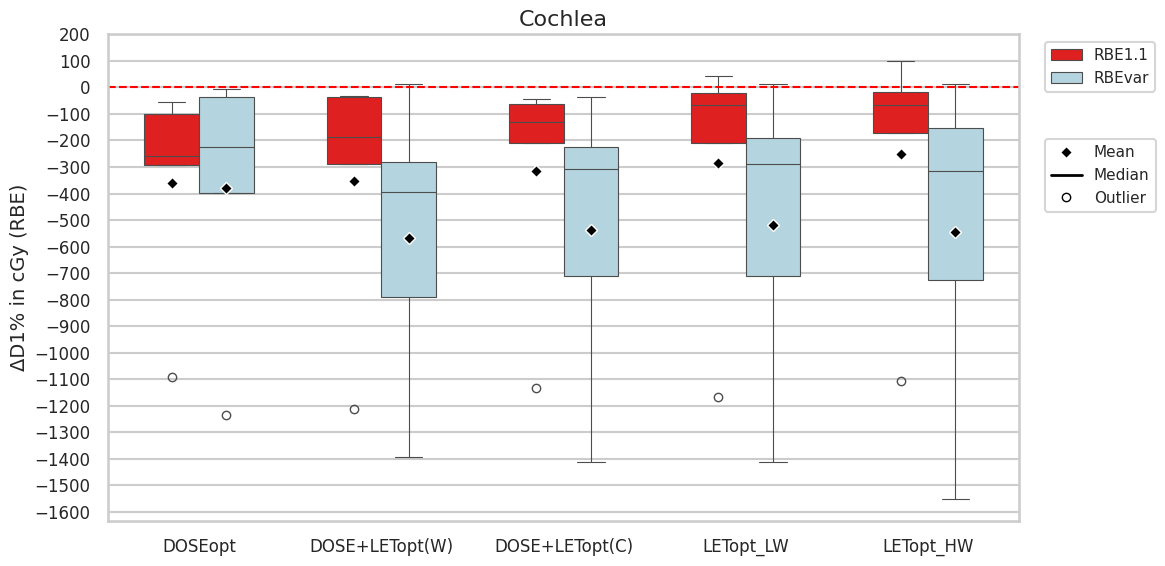

In [ ]:


    # Each group has an associated group name and hue condition
# Cochlea

# List of numerical values grouped into sublists
data_matrix = [
    [-257,  -1090,  -294, -54,  -99],   # DOSEopt - RBE1.1
    [-397,  -1234,  -224, -38,  -6],   # DOSEopt - RBEvar
    [-290,  -35,  -1213,  -33,  -188],   # DOSE+LETopt(warm) - RBE1.1
    [-791,  -282, -1392,  14, -395],   # DOSE+LETopt(warm) - RBEvar
    [-211,  -43,  -63,  -1131,  -129],   # DOSE+LETopt(cold) - RBE1.1
    [-710,  -226, -36,  -1412,  -307],   # DOSE+LETopt(cold) - RBEvar
    [-208,  -1168,  42, -22,  -68],   # LETopt_LW - RBE1.1
    [-712,  -1411,  -190, 13, -287],   # LETopt_LW - RBEvar
    [-173,  -1106,  101,  -16,  -66],   # LETopt_HW - RBE1.1
    [-726,  -1550,  -153, 14, -315]   # LETopt_HW - RBEvar
]

# X-axis group label for each sublist
group_labels = [
    "DOSEopt", "DOSEopt",
    "DOSE+LETopt(W)", "DOSE+LETopt(W)", # Added comma here
    "DOSE+LETopt(C)", "DOSE+LETopt(C)", # Added comma here
    "LETopt_LW", "LETopt_LW", # Added comma here
    "LETopt_HW", "LETopt_HW" # Added comma here
]

# Hue category for each sublist (e.g., Treatment condition)
hue_labels = [
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar"
]

# Optional: Define specific colors for each hue
custom_colors = {
    "RBE1.1": "#FF0000",   # Red
    "RBEvar": "#ADD8E6"    # Blue
}

# Call the function to generate the plot
plot_whisker_from_2d_with_hue(
    data_matrix,
    group_labels,
    hue_labels,
    title="Cochlea",
    x_label="",
    y_label="ΔD1% in cGy (RBE)",
    custom_palette=custom_colors
)

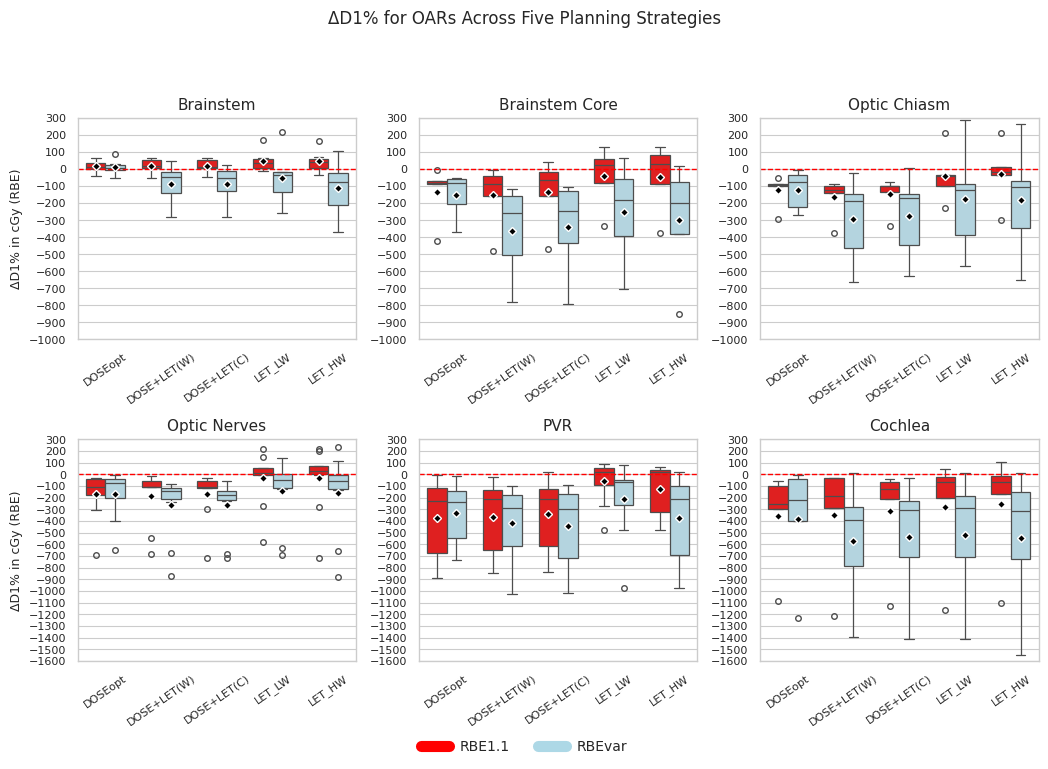

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


sns.set_theme(style="whitegrid", context="paper", font_scale=0.95)


# Common labels and colors
group_labels = [
    "DOSEopt","DOSEopt",
    "DOSE+LET(W)","DOSE+LET(W)",
    "DOSE+LET(C)","DOSE+LET(C)",
    "LET_LW","LET_LW",
    "LET_HW","LET_HW"
]
hue_labels = ["RBE1.1","RBEvar"] * 5
colors = {"RBE1.1": "#FF0000", "RBEvar": "#ADD8E6"}


# --------- DATA (exactly as provided) ---------

data = {
    "Optic Nerves": [
        [-39,-308,-108,-117,-691,-203,-44,-29,-45,-108],
        [-78,-397,-172,-42,-647,-216,-41,-10,-48,-78],
        [-58,-544,-109,-111,-688,-111,-38,-16,-57,-109],
        [-158,-869,-148,-113,-672,-235,-134,-89,-81,-148],
        [-62,-300,-121,-119,-714,-106,-57,-33,-36,-106],
        [-169,-682,-180,-138,-722,-231,-181,-57,-64,-180],
        [57,-269,9,54,-579,-2,-4,218,146,9],
        [-48,-635,-43,15,-694,-128,-88,112,142,-48],
        [72,-277,30,74,-721,24,-10,218,202,30],
        [-54,-661,-51,8,-881,-134,-102,112,236,-54]
    ],
    "PVR": [
        [-4,-10,-97,-686,-646,-812,-209,-193,-888,-251],
        [-14,-52,-133,-476,-660,-569,-197,-276,-732,-193],
        [-27,-21,-114,-722,-650,-848,-198,-194,-647,-227],
        [-102,-145,-142,-561,-684,-631,-297,-264,-1026,-290],
        [-4,16,-108,-706,-652,-839,-207,-174,-506,-221],
        [-92,-120,-139,-714,-719,-747,-302,-250,-1022,-298],
        [35,59,85,-112,-51,-272,54,11,-481,58],
        [-54,-64,83,-295,-186,-476,-72,-48,-976,-40],
        [21,34,62,-328,-297,-370,15,28,-481,52],
        [-122,-155,22,-728,-593,-744,-276,-55,-976,-93]
    ],
    "Brainstem": [
        [-42,0,23,40,1,66],
        [3,9,29,-56,-14,84],
        [3,64,13,-54,23,64],
        [-15,-168,-68,-285,-33,46],
        [4,66,5,-49,63,20],
        [-5,-157,-61,-284,24,-42],
        [-6,61,35,-11,36,169],
        [-18,-169,-45,-260,-28,213],
        [-4,67,35,-35,39,163],
        [-30,-240,-123,-372,-26,105]
    ],
    "Brainstem Core": [
        [-82,-70,-426,-6,-92],
        [-84,-209,-372,-61,-52],
        [-159,-45,-482,-5,-92],
        [-262,-506,-783,-117,-157],
        [-160,39,-471,-20,-66],
        [-248,-437,-794,-109,-133],
        [-85,57,-338,23,125],
        [-184,-393,-706,-60,64],
        [-88,128,-379,26,80],
        [-203,-381,-849,-75,19]
    ],
    "Optic Chiasm": [
        [-91,-96,-294,-54,-99],
        [-76,-273,-224,-38,-6],
        [-100,-141,-375,-122,-88],
        [-148,-463,-665,-187,-23],
        [-101,-134,-337,-99,-75],
        [-147,-448,-626,-171,7],
        [-39,-101,-229,-42,212],
        [-89,-389,-570,-125,287],
        [-36,9,-301,-20,207],
        [-73,-347,-651,-108,263]
    ],
    "Cochlea": [
        [-257,-1090,-294,-54,-99],
        [-397,-1234,-224,-38,-6],
        [-290,-35,-1213,-33,-188],
        [-791,-282,-1392,14,-395],
        [-211,-43,-63,-1131,-129],
        [-710,-226,-36,-1412,-307],
        [-208,-1168,42,-22,-68],
        [-712,-1411,-190,13,-287],
        [-173,-1106,101,-16,-66],
        [-726,-1550,-153,14,-315]
    ]
}


# --------- GLOBAL Y-RANGE AND TICKS ---------

all_vals = [v for m in data.values() for row in m for v in row]
ymin = int(np.floor(min(all_vals) / 100.0) * 100)
ymax = int(np.ceil(max(all_vals) / 100.0) * 100)
yticks = np.arange(ymin, ymax + 100, 100)


# --------- PER-SUBPLOT FUNCTION ---------

def oar_boxplot(ax, name):
    dm = data[name]
    flat = [v for row in dm for v in row]
    groups = [g for g, row in zip(group_labels, dm) for _ in row]
    hues = [h for h, row in zip(hue_labels, dm) for _ in row]
    df = pd.DataFrame({"Value": flat, "Plan": groups, "Category": hues})

    sns.boxplot(
        x="Plan", y="Value", hue="Category", data=df,
        palette=colors, width=0.7, linewidth=0.9, showmeans=True,
        meanprops=dict(marker="D", markerfacecolor="black",
                       markeredgecolor="white", markersize=4),
        fliersize=4, ax=ax
    )

    ax.set_title(name, fontsize=11)
    ax.set_xlabel("")
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.tick_params(axis="x", labelrotation=35, labelsize=8)   # ← increased one step vs original (e.g., 7→8)
    ax.tick_params(axis="y", labelsize=8)

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()


# --------- CREATE 3×2 FIGURE ---------

fig, axes = plt.subplots(2, 3, figsize=(11, 8.5), sharey=False)

order = [
    "Brainstem", "Brainstem Core",
    "Optic Chiasm", "Optic Nerves",
    "PVR", "Cochlea"
]

for ax, name in zip(axes.flatten(), order):
    oar_boxplot(ax, name)


# Apply limits: upper row clipped to -1000 cGy, lower row unchanged
for idx, ax in enumerate(axes.flatten()):
    ax.set_yticks(yticks)
    if idx < 3:
        ax.set_ylim(-1000, ymax)
    else:
        ax.set_ylim(ymin, ymax)

    if idx % 3 == 0:
        ax.set_ylabel("ΔD1% in cGy (RBE)", fontsize=9)
    else:
        ax.set_ylabel("")


fig.suptitle("ΔD1% for OARs Across Five Planning Strategies", fontsize=12)


# --------- GLOBAL LEGEND (without Median, Mean, Outlier) ---------

rbe11_proxy = Line2D([0], [0], color=colors["RBE1.1"], lw=8, label="RBE1.1")
rbevar_proxy = Line2D([0], [0], color=colors["RBEvar"], lw=8, label="RBEvar")

fig.legend(
    handles=[rbe11_proxy, rbevar_proxy],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.09),
    ncol=2,
    frameon=False,
    fontsize=10            # kept at original “small” level
)


fig.tight_layout(rect=[0.02, 0.12, 0.98, 0.93])

fig.savefig("OAR_D1_combined.png", dpi=600, bbox_inches="tight")
fig.savefig("OAR_D1_combined.pdf", dpi=600, bbox_inches="tight")
fig.savefig("OAR_D1_combined.jpg", dpi=600, bbox_inches="tight")
plt.show()

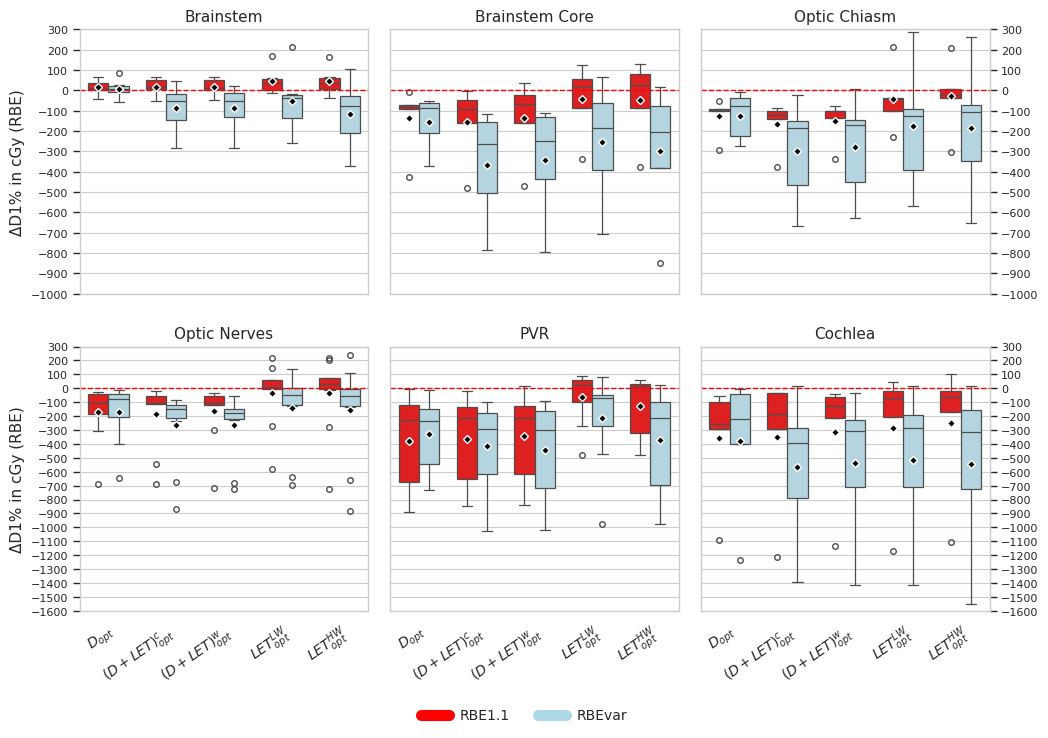

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


sns.set_theme(style="whitegrid", context="paper", font_scale=0.95)


# Common labels and colors
group_labels = [
    "DOSEopt","DOSEopt",
    "DOSE+LET(W)","DOSE+LET(W)",
    "DOSE+LET(C)","DOSE+LET(C)",
    "LET_LW","LET_LW",
    "LET_HW","LET_HW"
]
hue_labels = ["RBE1.1", "RBEvar"] * 5
colors = {"RBE1.1": "#FF0000", "RBEvar": "#ADD8E6"}

# X-axis labels as in the attached image
xlabels = [
    r"$D_{opt}$",
    r"$(D+LET)^{c}_{opt}$",
    r"$(D+LET)^{w}_{opt}$",
    r"$LET^{LW}_{opt}$",
    r"$LET^{HW}_{opt}$"
]


# --------- DATA (exactly as provided) ---------
data = {
    "Optic Nerves": [
        [-39,-308,-108,-117,-691,-203,-44,-29,-45,-108],
        [-78,-397,-172,-42,-647,-216,-41,-10,-48,-78],
        [-58,-544,-109,-111,-688,-111,-38,-16,-57,-109],
        [-158,-869,-148,-113,-672,-235,-134,-89,-81,-148],
        [-62,-300,-121,-119,-714,-106,-57,-33,-36,-106],
        [-169,-682,-180,-138,-722,-231,-181,-57,-64,-180],
        [57,-269,9,54,-579,-2,-4,218,146,9],
        [-48,-635,-43,15,-694,-128,-88,112,142,-48],
        [72,-277,30,74,-721,24,-10,218,202,30],
        [-54,-661,-51,8,-881,-134,-102,112,236,-54]
    ],
    "PVR": [
        [-4,-10,-97,-686,-646,-812,-209,-193,-888,-251],
        [-14,-52,-133,-476,-660,-569,-197,-276,-732,-193],
        [-27,-21,-114,-722,-650,-848,-198,-194,-647,-227],
        [-102,-145,-142,-561,-684,-631,-297,-264,-1026,-290],
        [-4,16,-108,-706,-652,-839,-207,-174,-506,-221],
        [-92,-120,-139,-714,-719,-747,-302,-250,-1022,-298],
        [35,59,85,-112,-51,-272,54,11,-481,58],
        [-54,-64,83,-295,-186,-476,-72,-48,-976,-40],
        [21,34,62,-328,-297,-370,15,28,-481,52],
        [-122,-155,22,-728,-593,-744,-276,-55,-976,-93]
    ],
    "Brainstem": [
        [-42,0,23,40,1,66],
        [3,9,29,-56,-14,84],
        [3,64,13,-54,23,64],
        [-15,-168,-68,-285,-33,46],
        [4,66,5,-49,63,20],
        [-5,-157,-61,-284,24,-42],
        [-6,61,35,-11,36,169],
        [-18,-169,-45,-260,-28,213],
        [-4,67,35,-35,39,163],
        [-30,-240,-123,-372,-26,105]
    ],
    "Brainstem Core": [
        [-82,-70,-426,-6,-92],
        [-84,-209,-372,-61,-52],
        [-159,-45,-482,-5,-92],
        [-262,-506,-783,-117,-157],
        [-160,39,-471,-20,-66],
        [-248,-437,-794,-109,-133],
        [-85,57,-338,23,125],
        [-184,-393,-706,-60,64],
        [-88,128,-379,26,80],
        [-203,-381,-849,-75,19]
    ],
    "Optic Chiasm": [
        [-91,-96,-294,-54,-99],
        [-76,-273,-224,-38,-6],
        [-100,-141,-375,-122,-88],
        [-148,-463,-665,-187,-23],
        [-101,-134,-337,-99,-75],
        [-147,-448,-626,-171,7],
        [-39,-101,-229,-42,212],
        [-89,-389,-570,-125,287],
        [-36,9,-301,-20,207],
        [-73,-347,-651,-108,263]
    ],
    "Cochlea": [
        [-257,-1090,-294,-54,-99],
        [-397,-1234,-224,-38,-6],
        [-290,-35,-1213,-33,-188],
        [-791,-282,-1392,14,-395],
        [-211,-43,-63,-1131,-129],
        [-710,-226,-36,-1412,-307],
        [-208,-1168,42,-22,-68],
        [-712,-1411,-190,13,-287],
        [-173,-1106,101,-16,-66],
        [-726,-1550,-153,14,-315]
    ]
}


# --------- GLOBAL Y-RANGE AND TICKS ---------
all_vals = [v for m in data.values() for row in m for v in row]
ymin = int(np.floor(min(all_vals) / 100.0) * 100)
ymax = int(np.ceil(max(all_vals) / 100.0) * 100)
yticks = np.arange(ymin, ymax + 100, 100)


# --------- PER-SUBPLOT FUNCTION ---------
def oar_boxplot(ax, name):
    dm = data[name]
    flat = [v for row in dm for v in row]
    groups = [g for g, row in zip(group_labels, dm) for _ in row]
    hues = [h for h, row in zip(hue_labels, dm) for _ in row]
    df = pd.DataFrame({"Value": flat, "Plan": groups, "Category": hues})

    sns.boxplot(
        x="Plan", y="Value", hue="Category", data=df,
        palette=colors, width=0.7, linewidth=0.9, showmeans=True,
        meanprops=dict(marker="D", markerfacecolor="black",
                       markeredgecolor="white", markersize=4),
        fliersize=4, ax=ax
    )

    ax.set_title(name, fontsize=11)
    ax.set_xlabel("")
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.tick_params(axis="y", labelsize=8)

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()


# --------- CREATE 3×2 FIGURE ---------
fig, axes = plt.subplots(2, 3, figsize=(11, 8.5), sharey=False)

order = [
    "Brainstem", "Brainstem Core", "Optic Chiasm",
    "Optic Nerves", "PVR", "Cochlea"
]

for ax, name in zip(axes.flatten(), order):
    oar_boxplot(ax, name)

# Apply limits and axis formatting
for idx, ax in enumerate(axes.flatten()):
    ax.set_yticks(yticks)

    if idx < 3:
        ax.set_ylim(-1000, ymax)
    else:
        ax.set_ylim(ymin, ymax)

    if idx % 3 == 0:
        ax.set_ylabel("ΔD1% in cGy (RBE)", fontsize=11)
        ax.tick_params(axis='y', labelleft=True, labelright=False)
        ax.yaxis.set_ticks_position('left')
        ax.yaxis.set_label_position('left')

    elif idx % 3 == 1:
        ax.set_ylabel("")
        ax.tick_params(axis='y', labelleft=False, labelright=False)

    else:
        ax.set_ylabel("")
        ax.tick_params(axis='y', labelleft=False, labelright=True)
        ax.yaxis.set_ticks_position('right')
        ax.yaxis.set_label_position('right')
        ax.tick_params(axis="y", labelsize=8)

    ax.tick_params(axis="x", labelsize=8)

# Hide x tick labels on top row
for ax in axes[0, :]:
    ax.set_xticklabels([])

# Set custom x-axis labels on bottom row with rotation
for ax in axes[1, :]:
    ax.set_xticks(np.arange(len(xlabels)))
    ax.set_xticklabels(xlabels, fontsize=10, rotation=35, ha='right', rotation_mode='anchor')

# Global legend
rbe11_proxy = Line2D([0], [0], color=colors["RBE1.1"], lw=8, label="RBE1.1")
rbevar_proxy = Line2D([0], [0], color=colors["RBEvar"], lw=8, label="RBEvar")

fig.legend(
    handles=[rbe11_proxy, rbevar_proxy],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.08),
    ncol=2,
    frameon=False,
    fontsize=10
)

# Layout
fig.tight_layout(rect=[0.02, 0.12, 0.98, 0.95])
fig.subplots_adjust(wspace=0.075, hspace=0.2)

fig.savefig("OAR_D1_combined.png", dpi=600, bbox_inches="tight")
fig.savefig("OAR_D1_combined.pdf", dpi=600, bbox_inches="tight")
fig.savefig("OAR_D1_combined.jpg", dpi=600, bbox_inches="tight")
fig.savefig("OAR_D1_combined.eps", format="eps", bbox_inches="tight")
plt.show()

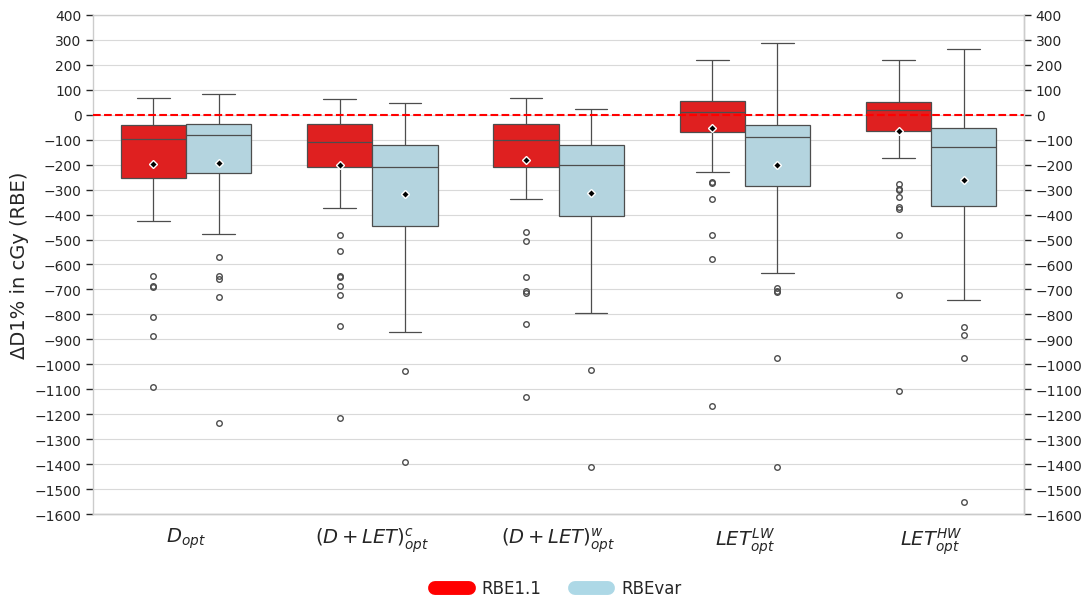

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


sns.set_theme(style="whitegrid", context="paper", font_scale=0.95)


data_matrix = [
    [-42, 0, 23, 40, 1, 66, 12, -82, -70, -426, -6, -92, -82, -39, -308, -108, -117, -691, -203, -44, -29, -45, -108, -91, -96, -294, -54, -99, -96, -257, -1090, -294, -54, -99, -257, -4, -10, -97, -686, -646, -812, -209, -193, -888, -251, -230],
    [3, 9, 29, -56, -14, 84, 6, -84, -209, -372, -61, -52, -84, -78, -397, -172, -42, -647, -216, -41, -10, -48, -78, -76, -273, -224, -38, -6, -76, -397, -1234, -224, -38, -6, -224, -14, -52, -133, -476, -660, -569, -197, -276, -732, -193, -236.5],
    [3, 64, 13, -54, 23, 64, 18, -159, -45, -482, -5, -92, -92, -58, -544, -109, -111, -688, -111, -38, -16, -57, -109, -100, -141, -375, -122, -88, -122, -290, -35, -1213, -33, -188, -188, -27, -21, -114, -722, -650, -848, -198, -194, -647, -227, -212.5],
    [-15, -168, -68, -285, -33, 46, -50.5, -262, -506, -783, -117, -157, -262, -158, -869, -148, -113, -672, -235, -134, -89, -81, -148, -148, -463, -665, -187, -23, -187, -791, -282, -1392, 14, -395, -395, -102, -145, -142, -561, -684, -631, -297, -264, -1026, -290, -293.55],
    [4, 66, 5, -49, 63, 20, 12.5, -160, 39, -471, -20, -66, -66, -62, -300, -121, -119, -714, -106, -57, -33, -36, -106, -101, -134, -337, -99, -75, -101, -211, -43, -63, -1131, -129, -129, -4, 16, -108, -706, -652, -839, -207, -174, -506, -221, -214],
    [-5, -157, -61, -284, 24, -42, -51.5, -248, -437, -794, -109, -133, -248, -169, -682, -180, -138, -722, -231, -181, -57, -64, -180, -147, -448, -626, -171, 7, -171, -710, -226, -36, -1412, -307, -307, -92, -120, -139, -714, -719, -747, -302, -250, -1022, -298, -300],
    [-6, 61, 35, -11, 36, 169, 35.5, -85, 57, -338, 23, 125, 23, 57, -269, 9, 54, -579, -2, -4, 218, 146, 9, -39, -101, -229, -42, 212, -42, -208, -1168, 42, -22, -68, -68, 35, 59, 85, -112, -51, -272, 54, 11, -481, 58, 23],
    [-18, -169, -45, -260, -28, 213, -36.5, -184, -393, -706, -60, 64, -184, -48, -635, -43, 15, -694, -128, -88, 112, 142, -48, -89, -389, -570, -125, 287, -125, -712, -1411, -190, 13, -287, -287, -54, -64, 83, -295, -186, -476, -72, -48, -976, -40, -68],
    [-4, 67, 35, -35, 39, 163, 37, -88, 128, -379, 26, 80, 26, 72, -277, 30, 74, -721, 24, -10, 218, 202, 30, -36, 9, -301, -20, 207, -20, -173, -1106, 101, -16, -66, -66, 21, 34, 62, -328, -297, -370, 15, 28, -481, 52, 18],
    [-30, -240, -123, -372, -26, 105, -76.5, -203, -381, -849, -75, 19, -203, -54, -661, -51, 8, -881, -134, -102, 112, 236, -54, -73, -347, -651, -108, 263, -108, -726, -1550, -153, 14, -315, -315, -122, -155, 22, -728, -593, -744, -276, -55, -976, -93, -215.5]
]

group_labels = [
    "DOSEopt", "DOSEopt",
    "DOSE+LETopt(W)", "DOSE+LETopt(W)",
    "DOSE+LETopt(C)", "DOSE+LETopt(C)",
    "LETopt_LW", "LETopt_LW",
    "LETopt_HW", "LETopt_HW"
]

hue_labels = [
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar",
    "RBE1.1", "RBEvar"
]

custom_colors = {
    "RBE1.1": "#FF0000",
    "RBEvar": "#ADD8E6"
}

xlabels = [
    r"$D_{opt}$",
    r"$(D+LET)^{c}_{opt}$",
    r"$(D+LET)^{w}_{opt}$",
    r"$LET^{LW}_{opt}$",
    r"$LET^{HW}_{opt}$"
]


def plot_whisker_from_2d_with_hue(
    data_matrix, group_labels, hue_labels,
    title="", x_label="", y_label="",
    custom_palette=None, y_title_fontsize=14
):
    flat = [v for row in data_matrix for v in row]
    groups = [g for g, row in zip(group_labels, data_matrix) for _ in row]
    hues = [h for h, row in zip(hue_labels, data_matrix) for _ in row]
    df = pd.DataFrame({"Value": flat, "Plan": groups, "Category": hues})

    fig, ax = plt.subplots(figsize=(11, 6.2))
    ax.set_axisbelow(True)

    sns.boxplot(
        x="Plan", y="Value", hue="Category", data=df,
        palette=custom_palette, width=0.7, linewidth=0.9, showmeans=True,
        meanprops=dict(marker="D", markerfacecolor="black",
                       markeredgecolor="white", markersize=4),
        fliersize=4, ax=ax, zorder=3
    )

    ax.grid(True, axis="y", color="0.85", linewidth=0.8, zorder=0)

    ax.set_title("")
    ax.set_xlabel(x_label, rotation=0, labelpad=10)
    ax.set_ylabel(y_label, fontsize=y_title_fontsize)
    ax.set_ylim(-1600, 400)
    ax.set_yticks(np.arange(400, -1601, -100))
    ax.tick_params(axis="y", labelsize=10)

    ax.axhline(0, color="red", linestyle="--", linewidth=1.5, zorder=4)

    ax.set_xticks(np.arange(len(xlabels)))
    ax.set_xticklabels(xlabels, fontsize=14, rotation=0, ha="center")

    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks(ax.get_yticks())
    ax2.set_yticklabels(ax.get_yticklabels())
    ax2.tick_params(axis="y", labelsize=10)
    ax2.grid(False)
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    rbe11_proxy = Line2D([0], [0], color=custom_palette["RBE1.1"], lw=10, label="RBE1.1")
    rbevar_proxy = Line2D([0], [0], color=custom_palette["RBEvar"], lw=10, label="RBEvar")
    ax.legend(
        handles=[rbe11_proxy, rbevar_proxy],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.10),
        ncol=2,
        frameon=False,
        fontsize=12
    )

    plt.tight_layout()
    return fig, ax


fig, ax = plot_whisker_from_2d_with_hue(
    data_matrix,
    group_labels,
    hue_labels,
    title="",
    x_label="",
    y_label="ΔD1% in cGy (RBE)",
    custom_palette=custom_colors,
    y_title_fontsize=14
)

fig.savefig("OAR_D1_OveralGain.pdf", bbox_inches="tight")
fig.savefig("OAR_D1_OveralGain.jpg", dpi=600, bbox_inches="tight")
fig.savefig("OAR_D1_OveralGain.eps", format="eps", bbox_inches="tight")
plt.show()